In [1]:
import time
import pandas as pd
import json
import numpy as np
from datetime import datetime
from datetime import timezone
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap
import numpy as np
# import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
def remove_specific_cycles(data_loader, indices_to_remove):
    """
    Excludes specific indices from every key in the dataset.
    indices_to_remove: list of integers (e.g., [1, 3, 6])
    """
    cleaned_data = {}
    
    for key in data_loader.files:
        original_list = list(data_loader[key])
        # Keep only the items whose index is NOT in our 'remove' list
        cleaned_data[key] = [
            cycle for i, cycle in enumerate(original_list) 
            if i not in indices_to_remove
        ]
        
    return cleaned_data

def get_cycle_stats(data_source, param_prefix, leg, norm_points=100):
    """
    Interpolates cycles for a specific leg/parameter and calculates mean/std.
    """
    key = f'{param_prefix}_{leg}'
    if key not in data_source:
        return None, None, None

    raw_cycles = data_source[key]
    normalized_list = []
    

    for j, cycle in enumerate(raw_cycles):
            
        x_old = np.linspace(0, 100, len(cycle))
        x_new = np.linspace(0, 100, norm_points)
        norm_cycle = np.interp(x_new, x_old, cycle)
        normalized_list.append(norm_cycle)
    
    if not normalized_list:
        return None, None, None

    norm_matrix = np.array(normalized_list)
    mean_vals = np.mean(norm_matrix, axis=0)
    std_vals = np.std(norm_matrix, axis=0)
    x_axis = np.linspace(0, 100, norm_points)

    return x_axis, mean_vals, std_vals

In [5]:
def load_cycles_from_npz(filename):
    """
    Loads a flattened .npz file and reconstructs the nested dictionary.
    """
    data = np.load(filename)
    reconstructed = {}
    
    for key in data.files:
        # Split the key (e.g., 'rough_foot_force')
        # We use rsplit once from the right to handle sensor names with underscores
        parts = key.split('_', 1) 
        if len(parts) < 2: continue
        
        terrain, sensor = parts[0], parts[1]
        
        if terrain not in reconstructed:
            reconstructed[terrain] = {}
        
        # Convert the (N, 100, F) array back into a list of (100, F) arrays
        # This makes it compatible with your existing segment_all_trials output
        reconstructed[terrain][sensor] = [cycle for cycle in data[key]]
        
    print(f"Loaded {len(reconstructed)} terrains from {filename}")
    return reconstructed

# --- Execution ---
dataset = load_cycles_from_npz('walking_terrain_datasets.npz')

Loaded 5 terrains from walking_terrain_datasets.npz


In [8]:
name_joints = ['FR_J1', 'FR_J2', 'FR_J3', 'FR_J4', 
 'BR_J1', 'BR_J2', 'BR_J3', 'BR_J4', 
 'FL_J1', 'FL_J2', 'FL_J3', 'FL_J4', 
 'BL_J1', 'BL_J2', 'BL_J3', 'BL_J4']

name_legs = ['FR', 'BR', 'FL', 'BL']

# Plot show

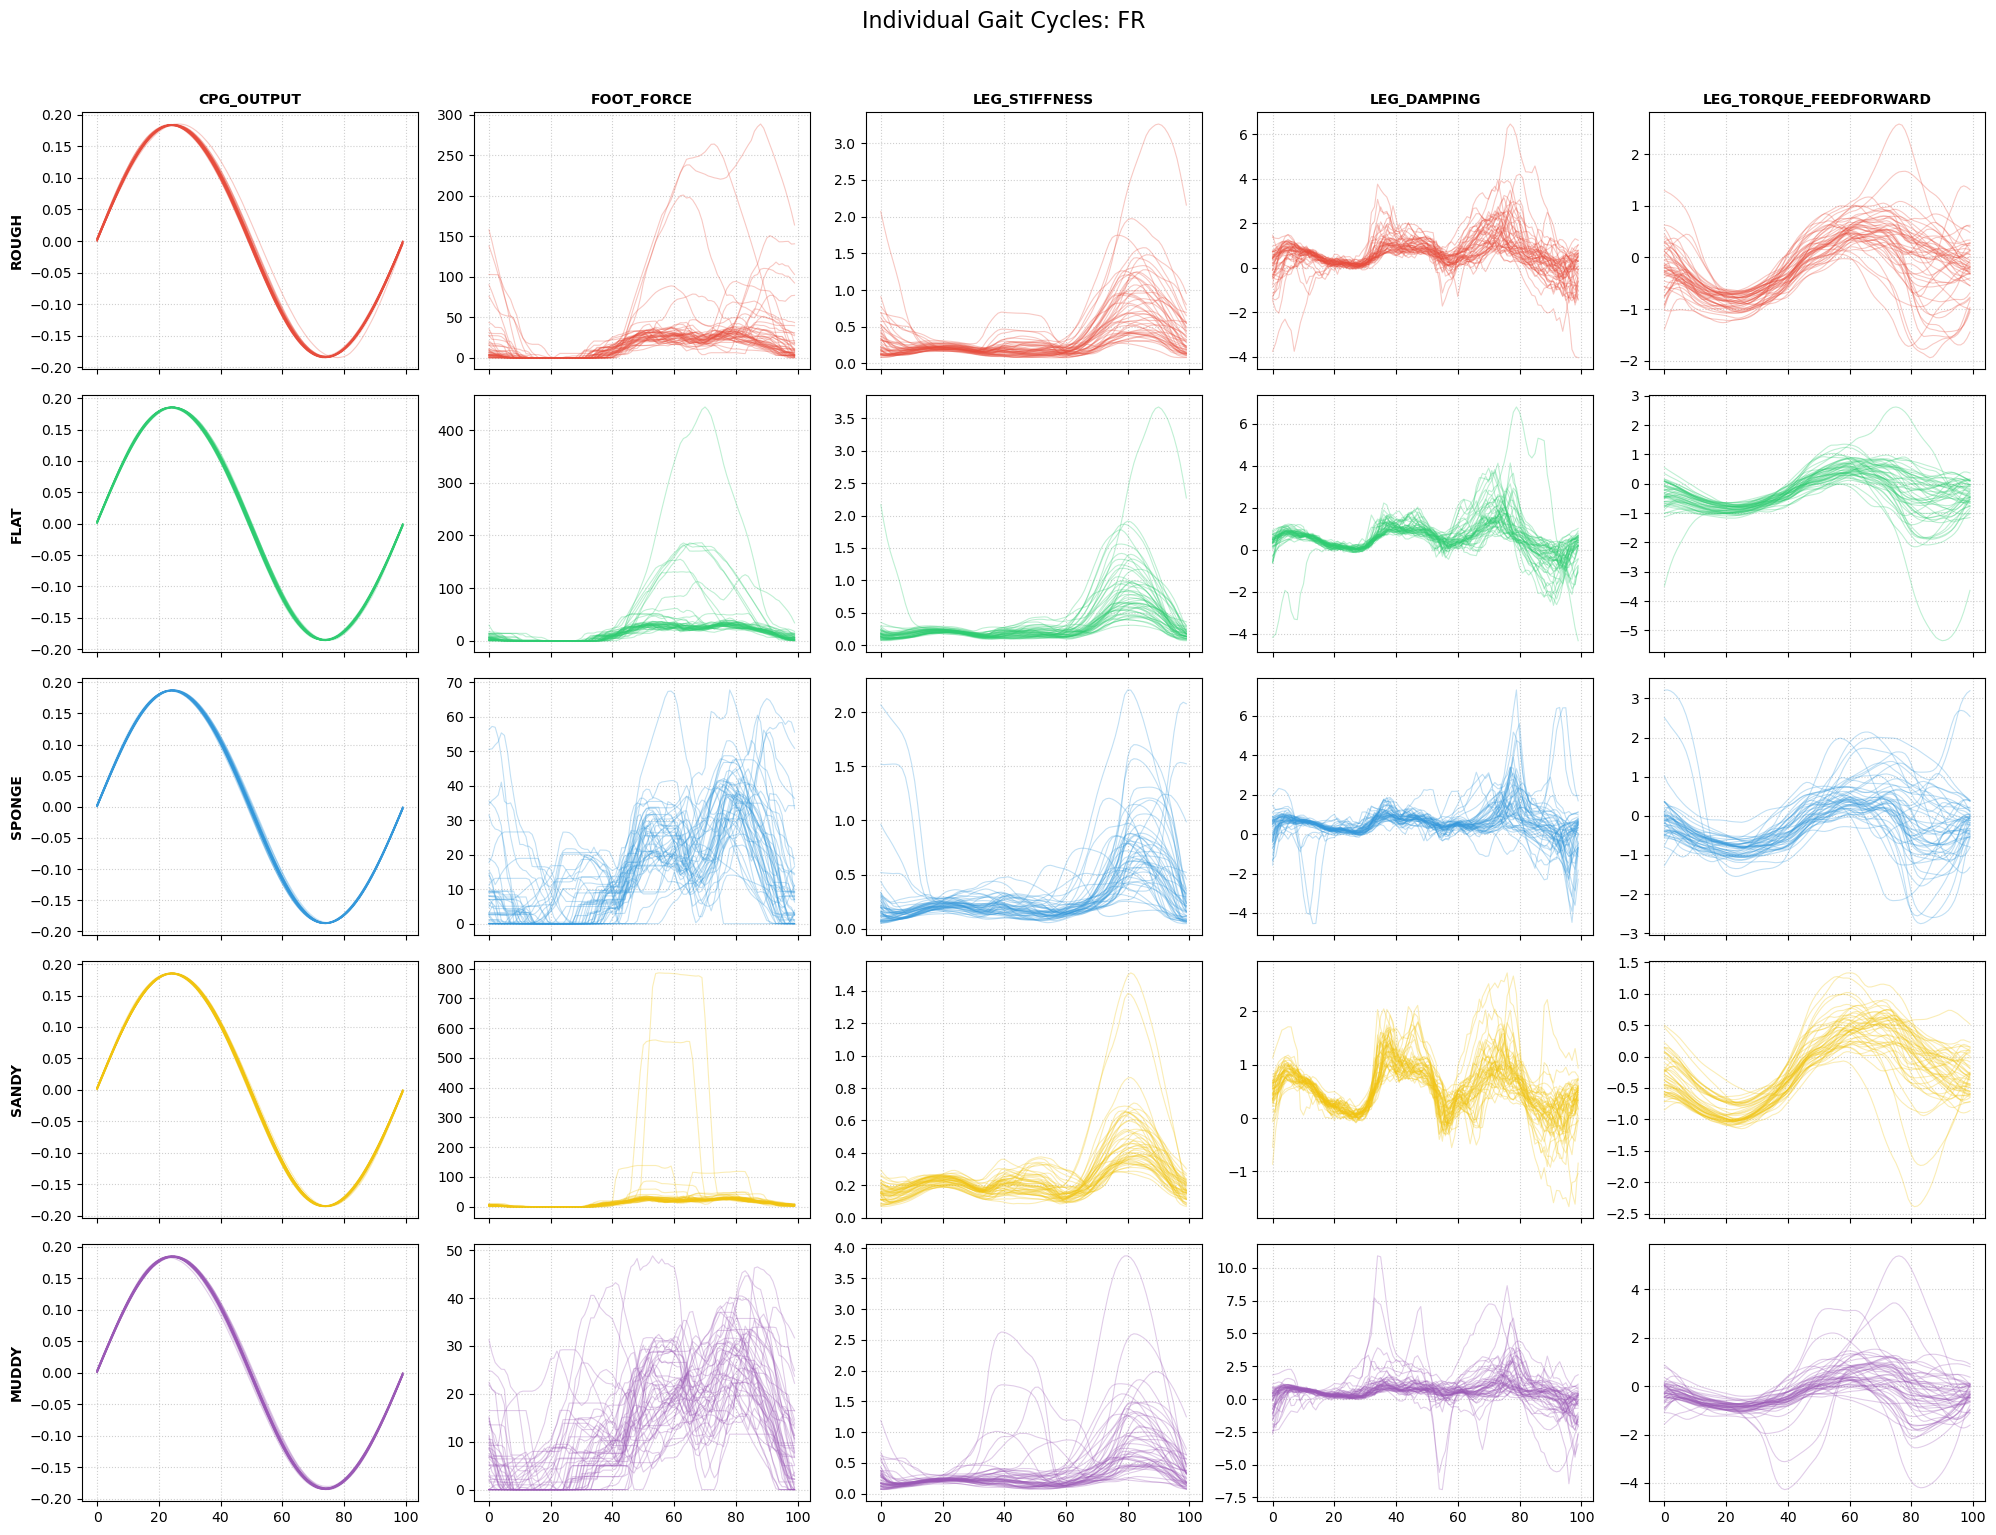

In [13]:
def plot_all_individual_cycles(cycle_results, sensor_list, feature_idx=0):
    """
    Plots every single cycle for every terrain to see the raw distribution.
    """
    terrains = list(cycle_results.keys())
    num_terrains = len(terrains)
    num_sensors = len(sensor_list)
    
    colors = {
        'flat': '#2ecc71', 'rough': '#e74c3c', 'sponge': '#3498db', 
        'sandy': '#f1c40f', 'muddy': '#9b59b6'
    }

    # Use a dynamic title based on the index
    # We try to find the name from the global scope, otherwise use the index number
    try:
        # Check if the first sensor in the list is a leg or joint sensor
        is_joint = 'joint' in sensor_list[0]
        feature_name = name_joints[feature_idx] if is_joint else name_legs[feature_idx]
    except (NameError, IndexError):
        feature_name = f"Index {feature_idx}"

    fig, axes = plt.subplots(num_terrains, num_sensors, 
                               figsize=(4 * num_sensors, 3 * num_terrains), 
                               sharex=True, squeeze=False) # squeeze=False keeps axes 2D (rows, cols)

    for t_idx, terrain in enumerate(terrains):
        for s_idx, sensor in enumerate(sensor_list):
            ax = axes[t_idx, s_idx]
            
            # Use .get() to avoid KeyError if a sensor is missing for a terrain
            cycles = cycle_results.get(terrain, {}).get(sensor, [])
            
            if not cycles or len(cycles) == 0:
                ax.text(0.5, 0.5, 'No Data', ha='center', transform=ax.transAxes)
                continue
            
            color = colors.get(terrain, 'black')
            
            # Plot every single cycle
            for cycle in cycles:
                # cycle shape is (100, num_features)
                ax.plot(cycle[:, feature_idx], color=color, alpha=0.3, linewidth=0.8)
            
            # Formatting titles only for the top row
            if t_idx == 0:
                ax.set_title(f"{sensor.upper()}", fontsize=10, fontweight='bold')
            
            # Formatting labels only for the first column
            if s_idx == 0:
                ax.set_ylabel(f"{terrain.upper()}", fontsize=10, fontweight='bold')
            
            ax.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(f"Individual Gait Cycles: {feature_name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# --- Execution ---
sensors_to_plot = ['cpg_output', 'foot_force', 'leg_stiffness', 'leg_damping', 'leg_torque_feedforward']
plot_all_individual_cycles(dataset, sensors_to_plot, feature_idx=0)

In [10]:

def plot_all_sensors_comparison(cycle_results, sensor_list, feature_index=0, feature_name="Leg 0"):
    """
    Creates a vertical stack of subplots comparing multiple sensors across all terrains.
    """
    terrains = list(cycle_results.keys())
    colors = {'flat': 'green', 'rough': 'red', 'sponge': 'blue', 'sandy': 'orange', 'muddy': 'brown'}
    
    num_sensors = len(sensor_list)
    fig, axes = plt.subplots(num_sensors, 1, figsize=(5, 3 * num_sensors), sharex=True)
    
    # Ensure axes is iterable even if there's only one sensor
    if num_sensors == 1:
        axes = [axes]

    for i, sensor_name in enumerate(sensor_list):
        ax = axes[i]
        
        for terrain in terrains:
            # Check if data exists for this terrain/sensor combo
            cycles = cycle_results.get(terrain, {}).get(sensor_name, [])
            if not cycles:
                continue
                
            data_stack = np.stack(cycles)
            feature_data = data_stack[:, :, feature_index]
            
            mean_traj = np.mean(feature_data, axis=0)
            std_traj = np.std(feature_data, axis=0)
            
            x = np.arange(100)
            color = colors.get(terrain, 'black')
            
            ax.plot(x, mean_traj, label=terrain.capitalize(), color=color, linewidth=2)
            ax.fill_between(x, mean_traj - std_traj, mean_traj + std_traj, color=color, alpha=0.1)

        ax.set_ylabel("Value")
        ax.set_title(f"{sensor_name.replace('_', ' ').upper()}", fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Only put the legend on the top plot to keep it clean
        if i == 0:
            ax.legend(loc='upper right', ncol=2, fontsize='small')

    plt.xlabel("Gait Cycle (%)")
    plt.suptitle(f"Comparison Across Terrains - {feature_name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig("terrain_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

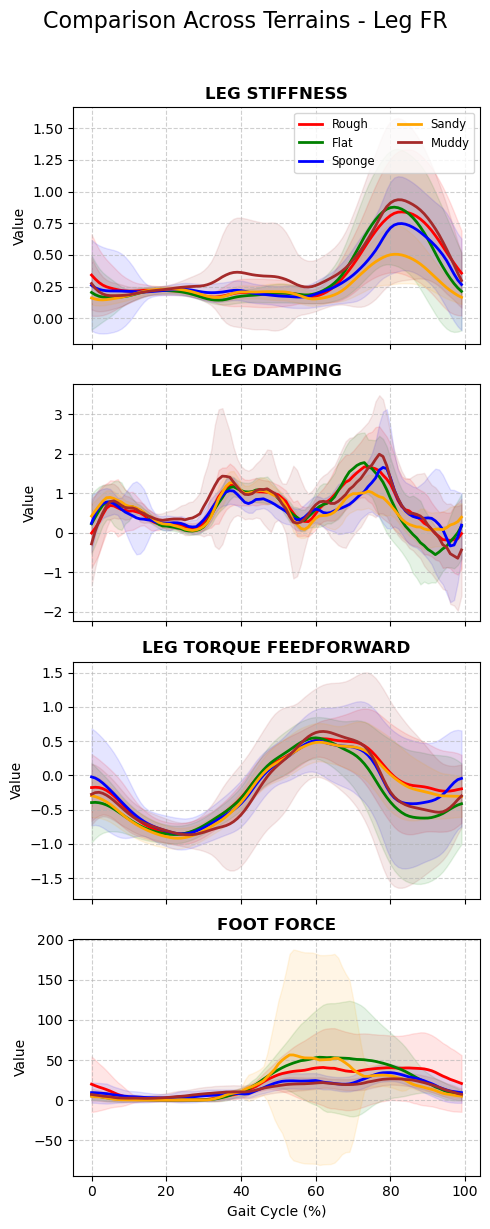

In [12]:
# List the sensors you want to visualize from the loaded file
sensors_to_plot = [
    'leg_stiffness', 
    'leg_damping', 
    'leg_torque_feedforward', 
    'foot_force'
]

# Use your previous subplot function
# Ensure name_legs is defined in your current environment
plot_all_sensors_comparison(
    dataset, 
    sensors_to_plot, 
    feature_index=0, 
    feature_name=f"Leg {name_legs[0]}"
)

# Train Process

In [ ]:
import numpy as np
import random

def split_gait_dataset(dataset, train_ratio=0.8, seed=42):
    """
    Splits the gait cycle dataset into training and testing sets.
    Safely handles sensors with mismatched cycle counts.
    """
    random.seed(seed)
    train_set = {}
    test_set = {}

    for terrain in dataset.keys():
        # 1. FIND THE MINIMUM CYCLE COUNT ACROSS ALL SENSORS
        # This ensures we don't try to access an index that doesn't exist for a sensor
        sensor_counts = [len(dataset[terrain][s]) for s in dataset[terrain].keys()]
        if not sensor_counts:
            continue
            
        min_cycles = min(sensor_counts)
        
        # 2. Generate indices based on the shortest sensor stream
        indices = list(range(min_cycles))
        random.shuffle(indices)
        
        split_idx = int(min_cycles * train_ratio)
        train_indices = indices[:split_idx]
        test_indices = indices[split_idx:]
        
        train_set[terrain] = {}
        test_set[terrain] = {}

        # 3. Distribute cycles
        for sensor in dataset[terrain].keys():
            all_cycles = dataset[terrain][sensor]
            # We only take the cycles up to min_cycles to stay synchronized
            train_set[terrain][sensor] = [all_cycles[i] for i in train_indices]
            test_set[terrain][sensor] = [all_cycles[i] for i in test_indices]
            
        print(f"Terrain {terrain.upper()}: Used {min_cycles} synchronized cycles. "
              f"({len(train_indices)} train, {len(test_indices)} test)")

    return train_set, test_set

# --- Execution ---
train_data, test_data = split_gait_dataset(dataset, train_ratio=0.8)

Terrain ROUGH: Used 17 synchronized cycles. (13 train, 4 test)
Terrain FLAT: Used 16 synchronized cycles. (12 train, 4 test)
Terrain SPONGE: Used 15 synchronized cycles. (12 train, 3 test)
Terrain SANDY: Used 16 synchronized cycles. (12 train, 4 test)
Terrain MUDDY: Used 16 synchronized cycles. (12 train, 4 test)


In [16]:
def prepare_xy(dataset, sensor_name):
    """
    Converts dictionary to X (data) and y (labels) arrays for a specific sensor.
    """
    X = []
    y = []
    terrain_mapping = {name: i for i, name in enumerate(dataset.keys())}
    
    for terrain, sensors in dataset.items():
        if sensor_name in sensors:
            cycles = sensors[sensor_name]
            X.extend(cycles)
            y.extend([terrain_mapping[terrain]] * len(cycles))
            
    return np.array(X), np.array(y), terrain_mapping

# Example: Prepare data using 'foot_force'
X_train, y_train, mapping = prepare_xy(train_data, 'foot_force')
X_test, y_test, _ = prepare_xy(test_data, 'foot_force')

print(f"X_train shape: {X_train.shape}") # (Samples, 100, Features)
print(f"Labels mapping: {mapping}")

X_train shape: (61, 100, 5)
Labels mapping: {'rough': 0, 'flat': 1, 'sponge': 2, 'sandy': 3, 'muddy': 4}


Starting training on 61 gait cycles...
Iteration 1 complete
Iteration 2 complete
Iteration 3 complete
Iteration 4 complete
Iteration 5 complete
Iteration 6 complete
Iteration 7 complete
Iteration 8 complete
Iteration 9 complete
Iteration 10 complete
Model parameters saved to environment_classifier_model_1.npz
Saved 5 centroids, X_min: [ 0.05393851 -6.87710161 -5.34910896], range_val: [ 3.62002412 17.75879076  7.92179514], window: 45


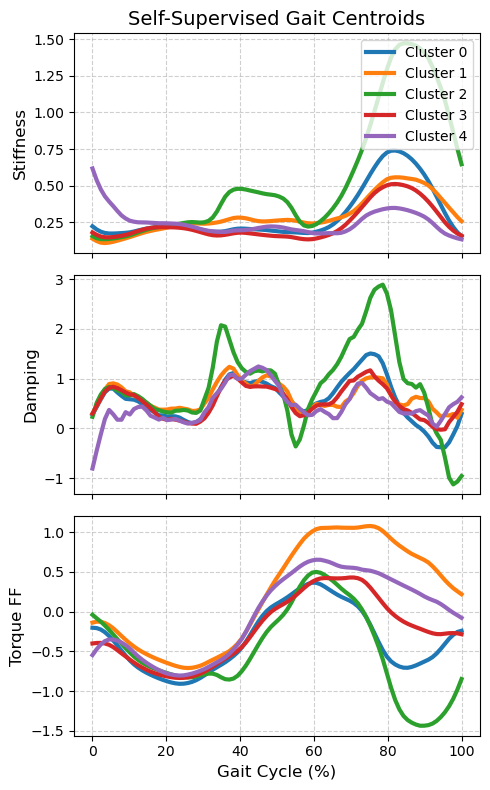

In [ ]:
from env_pred import TimeSeriesKMeans
# --- 1. Data Preparation ---
# We combine Stiffness, Damping, and Torque FF into a [90, 3] matrix per cycle
def prepare_multivariate_training_data(dataset, target_len=90):
    X_train_list = []
    
    # We iterate through all terrains in your training set
    for terrain in dataset.keys():
        stiffness_list = dataset[terrain]['leg_stiffness']
        damping_list   = dataset[terrain]['leg_damping']
        torque_ff_list = dataset[terrain]['leg_torque_feedforward']
        
        num_cycles = len(stiffness_list)
        
        for i in range(num_cycles):
            # Combine the 3 features for Leg 0 (index 0)
            # Each feature is shape (100,) after segmentation
            combined = np.stack([
                stiffness_list[i][:, 0], 
                damping_list[i][:, 0], 
                torque_ff_list[i][:, 0]
            ], axis=1) # Results in (100, 3)
            
            # Resample to the target length specified in your model
            # We'll use your class's resample method (need to instantiate first)
            X_train_list.append(combined)
            
    return X_train_list

# --- 2. Initialize and Train ---
# Create the model instance
# k=5 (one for each terrain type) or k=2 (Stance vs Swing focus)
gait_clusterer = TimeSeriesKMeans(k=5, max_iter=10, window=45)

# Resample cycles to 90 points as expected by the model
raw_training_cycles = prepare_multivariate_training_data(train_data)
X_resampled = [gait_clusterer.resample_cycle(c, target_len=90) for c in raw_training_cycles]

print(f"Starting training on {len(X_resampled)} gait cycles...")
centroids = gait_clusterer.fit(X_resampled)

# --- 3. Save and Plot ---
# gait_clusterer.save_model("environment_classifier_big_model_1.npz")
gait_clusterer.plot_centroids(feature_names=['Stiffness', 'Damping', 'Torque FF'])

### HOW TO PREDICT?

In [23]:
# Pick a random cycle from the test set
test_cycle_stiff = test_data['sandy']['leg_stiffness'][0][:, 0]
test_cycle_damp  = test_data['sandy']['leg_damping'][0][:, 0]
test_cycle_torque = test_data['sandy']['leg_torque_feedforward'][0][:, 0]

# Combine and resample
test_input = np.stack([test_cycle_stiff, test_cycle_damp, test_cycle_torque], axis=1)
test_input_resampled = gait_clusterer.resample_cycle(test_input, target_len=90)

# Predict
cluster_id, uncertainty = gait_clusterer.predict(test_input_resampled)

print(f"Predicted Cluster: {cluster_id}")
print(f"Uncertainty (0-1): {uncertainty:.4f}")

Predicted Cluster: 1
Uncertainty (0-1): 0.9032


Validating model on test set...


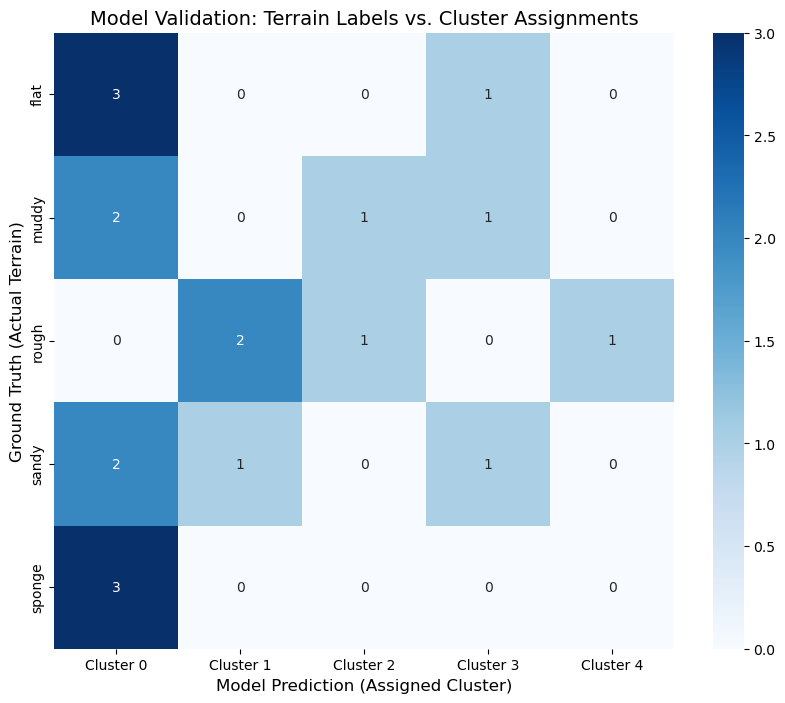


Classification Report:
              precision    recall  f1-score   support

   Cluster 0       0.00      0.00      0.00       0.0
   Cluster 1       0.00      0.00      0.00       0.0
   Cluster 2       0.00      0.00      0.00       0.0
   Cluster 3       0.00      0.00      0.00       0.0
   Cluster 4       0.00      0.00      0.00       0.0
        flat       0.00      0.00      0.00       4.0
       muddy       0.00      0.00      0.00       4.0
       rough       0.00      0.00      0.00       4.0
       sandy       0.00      0.00      0.00       4.0
      sponge       0.00      0.00      0.00       3.0

    accuracy                           0.00      19.0
   macro avg       0.00      0.00      0.00      19.0
weighted avg       0.00      0.00      0.00      19.0



/home/runj/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/runj/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/runj/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/runj/.local/lib/py

In [27]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def validate_clustering_performance(model, test_dataset):
    """
    Labels the test data using the known terrain types and validates 
    the TimeSeriesKMeans cluster assignments.
    """
    y_true = []
    y_pred = []
    
    terrains = list(test_dataset.keys())
    
    print("Validating model on test set...")
    
    for terrain in terrains:
        # Extract the triplet features for Leg 0
        stiff = test_dataset[terrain]['leg_stiffness']
        damp  = test_dataset[terrain]['leg_damping']
        tff   = test_dataset[terrain]['leg_torque_feedforward']
        
        for i in range(len(stiff)):
            # Prepare multivariate sample (100, 3)
            sample = np.stack([stiff[i][:, 0], damp[i][:, 0], tff[i][:, 0]], axis=1)
            
            # Resample to match model training length (90)
            sample_resampled = model.resample_cycle(sample, target_len=90)
            
            # Predict Cluster ID
            cluster_id, uncertainty = model.predict(sample_resampled)
            
            # Store ground truth and prediction
            y_true.append(terrain)
            y_pred.append(f"Cluster {cluster_id}")

    # --- 2. Confusion Matrix Visualization ---
    # Sort labels for clean display
    unique_clusters = sorted(list(set(y_pred)), key=lambda x: int(x.split()[-1]))
    unique_terrains = sorted(list(set(y_true)))
    
    cm = confusion_matrix(y_true, y_pred, labels=unique_terrains + unique_clusters)
    # We slice the CM to only show Terrains (rows) vs Clusters (columns)
    cm_slice = cm[:len(unique_terrains), len(unique_terrains):]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_slice, annot=True, fmt='d', cmap='Blues',
                xticklabels=unique_clusters, 
                yticklabels=unique_terrains)
    
    plt.title("Model Validation: Terrain Labels vs. Cluster Assignments", fontsize=14)
    plt.ylabel("Ground Truth (Actual Terrain)", fontsize=12)
    plt.xlabel("Model Prediction (Assigned Cluster)", fontsize=12)
    plt.show()

    # --- 3. Print Statistical Report ---
    print("\nClassification Report:")
    # Note: Accuracy here is tricky because K-Means labels are arbitrary IDs.
    # We look for high 'Precision' within specific clusters.
    print(classification_report(y_true, y_pred))

# --- Execution ---
validate_clustering_performance(gait_clusterer, test_data)

Validating model on test set...

TERRAIN         | ACCURACY   | DOMINANT CLUSTER
----------------------------------------
flat            |    75.00% | Cluster 0
muddy           |    50.00% | Cluster 0
rough           |    50.00% | Cluster 1
sandy           |    50.00% | Cluster 0
sponge          |   100.00% | Cluster 0
----------------------------------------
OVERALL SYSTEM ACCURACY:    63.16%



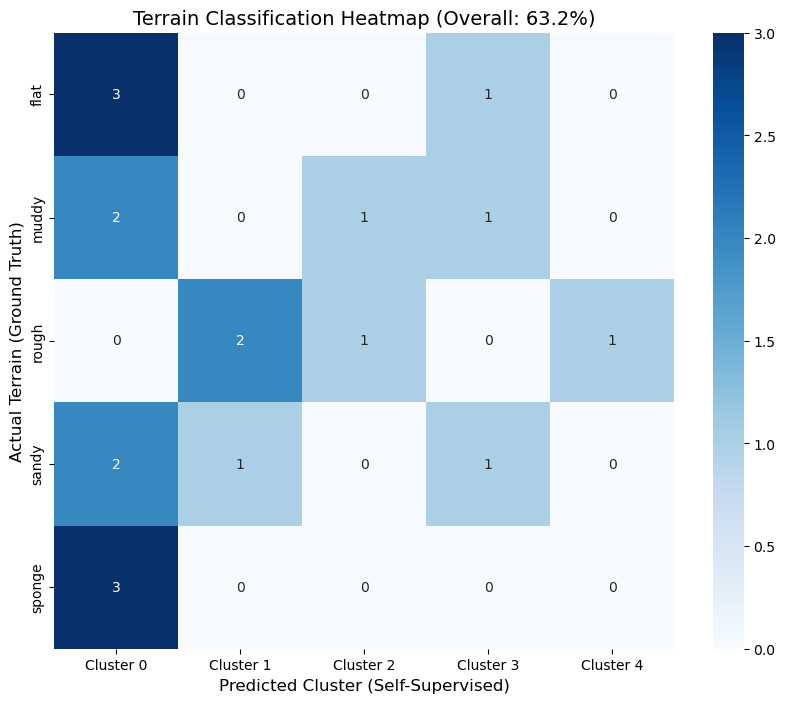

In [29]:
def validate_clustering_performance(model, test_dataset):
    """
    Validates TimeSeriesKMeans by mapping clusters to terrain labels 
    and reporting individual/overall accuracy.
    """
    y_true = []
    y_pred = []
    terrains = list(test_dataset.keys())
    
    print("Validating model on test set...")
    
    for terrain in terrains:
        stiff = test_dataset[terrain]['leg_stiffness']
        damp  = test_dataset[terrain]['leg_damping']
        tff   = test_dataset[terrain]['leg_torque_feedforward']
        
        for i in range(len(stiff)):
            sample = np.stack([stiff[i][:, 0], damp[i][:, 0], tff[i][:, 0]], axis=1)
            sample_resampled = model.resample_cycle(sample, target_len=90)
            cluster_id, _ = model.predict(sample_resampled)
            
            y_true.append(terrain)
            y_pred.append(f"Cluster {cluster_id}")

    # --- 1. Create Contingency Table for Accuracy Calculations ---
    df_results = pd.DataFrame({'Actual': y_true, 'Predicted': y_pred})
    contingency_table = pd.crosstab(df_results['Actual'], df_results['Predicted'])
    
    # --- 2. Calculate Accuracy Report ---
    print("\n" + "="*40)
    print(f"{'TERRAIN':<15} | {'ACCURACY':<10} | {'DOMINANT CLUSTER'}")
    print("-" * 40)
    
    total_correct = 0
    total_samples = len(y_true)
    
    for terrain in contingency_table.index:
        row = contingency_table.loc[terrain]
        max_samples = row.max()
        best_cluster = row.idxmax()
        terrain_total = row.sum()
        
        accuracy = (max_samples / terrain_total) * 100
        total_correct += max_samples
        
        print(f"{terrain:<15} | {accuracy:>8.2f}% | {best_cluster}")

    overall_accuracy = (total_correct / total_samples) * 100
    print("-" * 40)
    print(f"{'OVERALL SYSTEM ACCURACY:':<15} {overall_accuracy:>8.2f}%")
    print("="*40 + "\n")

    # --- 3. Confusion Matrix Visualization ---
    unique_clusters = sorted(list(set(y_pred)), key=lambda x: int(x.split()[-1]))
    unique_terrains = sorted(list(set(y_true)))
    
    # We slice the CM to show Terrains (rows) vs Clusters (columns)
    cm = confusion_matrix(y_true, y_pred, labels=unique_terrains + unique_clusters)
    cm_slice = cm[:len(unique_terrains), len(unique_terrains):]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_slice, annot=True, fmt='d', cmap='Blues',
                xticklabels=unique_clusters, yticklabels=unique_terrains)
    
    plt.title(f"Terrain Classification Heatmap (Overall: {overall_accuracy:.1f}%)", fontsize=14)
    plt.ylabel("Actual Terrain (Ground Truth)", fontsize=12)
    plt.xlabel("Predicted Cluster (Self-Supervised)", fontsize=12)
    plt.show()

# --- Execution ---
validate_clustering_performance(gait_clusterer, test_data)